<h1 style="font-size:34px; text-align:center; color: green; font-weight:bold; margin-bottom:5px;">
  HERBAL STORE ANALYTICS
</h1>

<h2 style="font-size:24px; text-align: center; font-weight:bold; color: #34A99D;">
  EXPLORATORY DATA ANALYSIS
</h2>

In [29]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [43]:
df = pd.read_csv("../data/sales.csv")

In [44]:
df.head()

,order_id,order_date,variant_sku,product_qty,subtotal_price,discount,tax,total_price,customer_id,first_name,...,city,state,country,postal_code,variant_price,cost_per_item,variant_inventory_qty,true_sku_margins,product_name,category
0,100,2025-11-01 01:45:23.000,HERB127,3,1350,27.00,67.5,1390.50,85,Naman,...,Surat,Gujarat,India,670662,450,360.0,5702,90.0,Amla Herbal Conditioner,Hair care
1,101,2025-11-01 02:19:55.000,HERB174,2,624,12.48,31.2,642.72,488,Hitesh,...,Solapur,Maharashtra,India,413001,312,249.6,5783,62.4,Sandalwood Herbal Soap,Skin care
2,102,2025-11-01 02:54:27.000,HERB002,2,360,7.20,18.0,370.80,111,Hamsa,...,Mysuru,Karnataka,India,569725,180,110.0,8760,70.0,Neem Face Wash,Skin care
3,103,2025-11-01 03:28:59.000,HERB130,4,720,14.40,36.0,741.60,507,Yashdeep,...,Saharanpur,Uttar Pradesh,India,247001,180,144.0,5812,36.0,Aloe Vera Night Cream,Skin care
4,104,2025-11-01 04:03:31.000,HERB010,3,642,12.84,32.1,661.26,1080,Arsh,...,Ajmer,Rajasthan,India,305001,214,171.2,3049,42.8,Giloy Juice,Wellness


# **Features:**

In [45]:
df.columns

Index(['order_id', 'order_date', 'variant_sku', 'product_qty',
       'subtotal_price', 'discount', 'tax', 'total_price', 'customer_id',
       'first_name', 'last_name', 'fullname', 'phone_number', 'email_id',
       'city', 'state', 'country', 'postal_code', 'variant_price',
       'cost_per_item', 'variant_inventory_qty', 'true_sku_margins',
       'product_name', 'category'],
      dtype='str')

In [46]:
df['order_date'] = pd.to_datetime(df['order_date'])


df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['day'] = df['order_date'].dt.day
df['weekday'] = df['order_date'].dt.day_name()

In [47]:
df['revenue'] = df['total_price']

In [48]:
df['profit'] = df['revenue'] - (df['product_qty'] * df['cost_per_item'])

In [49]:
df['discount_rate'] = df['discount'] / df['subtotal_price']

In [50]:
df['margin_pct'] = (df['profit'] / df['revenue']) * 100

In [85]:
df.to_csv('../data/sales.csv')

**REVENUE & PROFIT DISTRIBUTION**

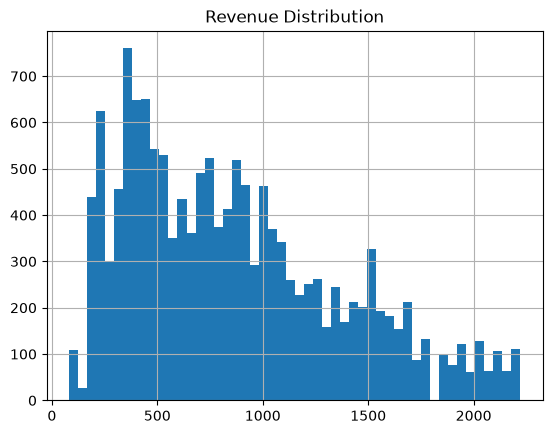

In [51]:
df['revenue'].hist(bins=50)
plt.title("Revenue Distribution")
plt.show()

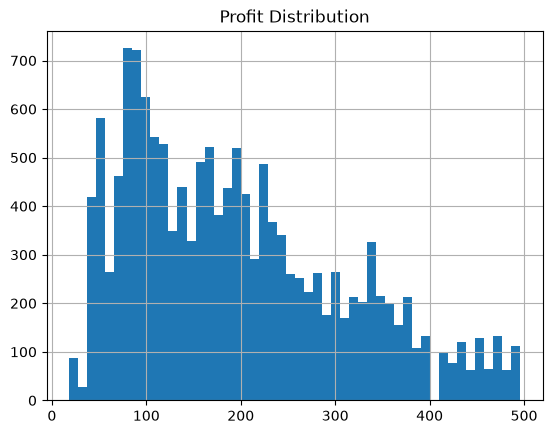

In [52]:
df['profit'].hist(bins=50)
plt.title("Profit Distribution")
plt.show()

**REVENUE TREND**

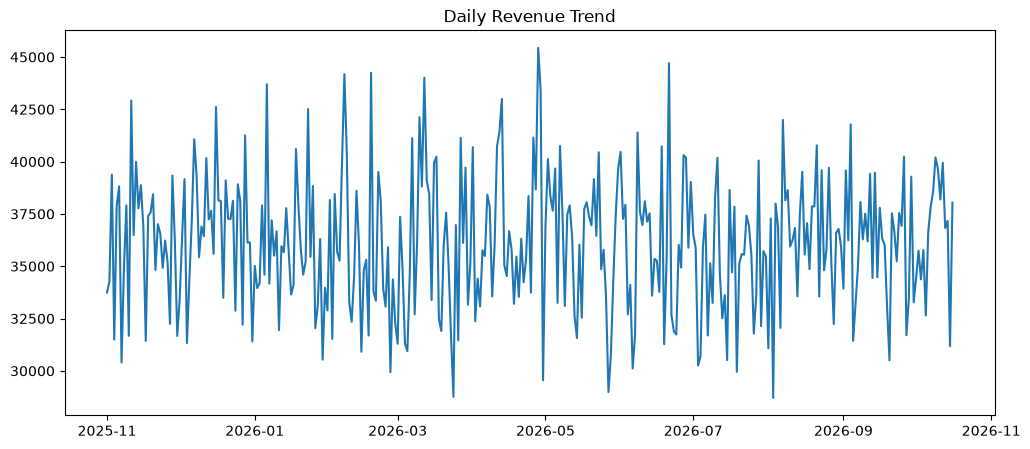

In [53]:
df = df.iloc[:-4]
df['date'] = df['order_date'].dt.date
daily_sales = df.groupby('date')['revenue'].sum().reset_index()

plt.figure(figsize=(12,5))
plt.plot(daily_sales['date'], daily_sales['revenue'])
plt.title("Daily Revenue Trend")
plt.savefig('../reports/daily_sales.png')
plt.show()

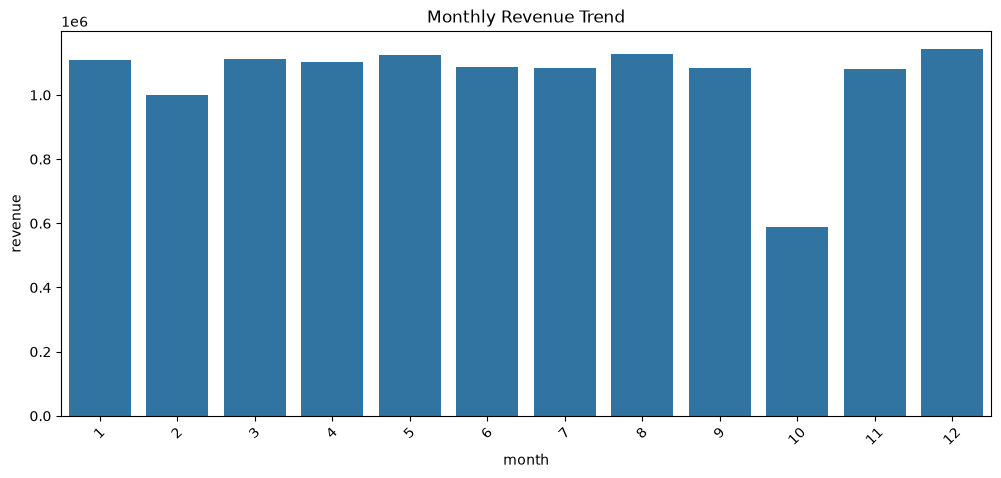

In [54]:
monthly_sales = df.groupby('month')['revenue'].sum().reset_index()
monthly_sales['month'] = monthly_sales['month'].astype(str)

plt.figure(figsize=(12,5))
sns.barplot(data=monthly_sales, x='month', y='revenue')
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.savefig('../reports/monthly_revenue_trend.png')
plt.show()

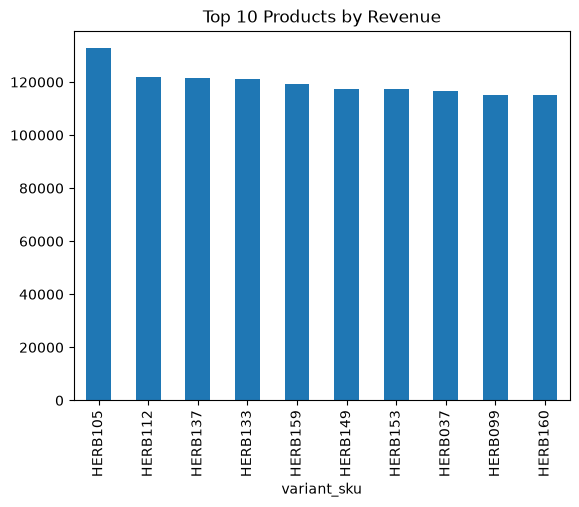

In [68]:
top_products = df.groupby('variant_sku')['revenue'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.savefig("../reports/top_products.png")
plt.show()

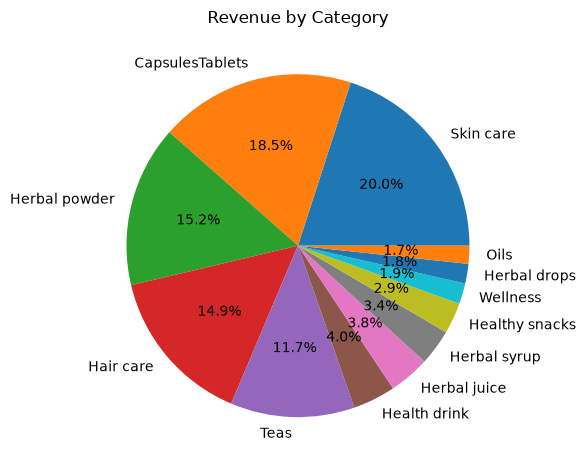

In [67]:
category_sales = df.groupby('category')['revenue'].sum().sort_values(ascending=False)

category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Revenue by Category")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../reports/revenue_cat.png")
plt.show()

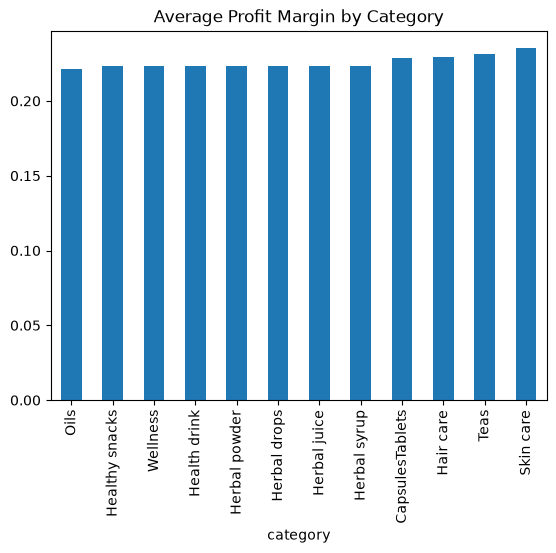

In [57]:
df['profit_margin'] = df['profit'] / df['revenue']

category_profit = df.groupby('category')['profit_margin'].mean()

category_profit.sort_values().plot(kind='bar')
plt.title("Average Profit Margin by Category")
plt.show()

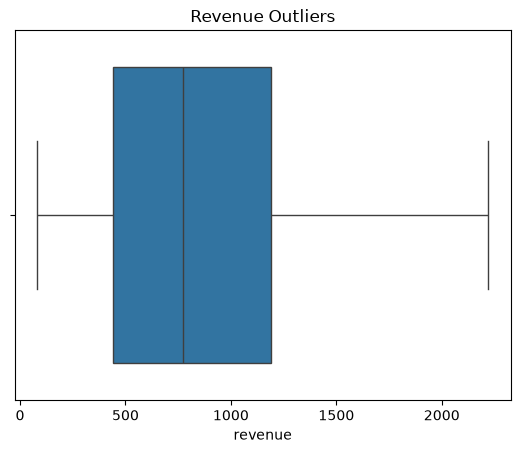

In [59]:
sns.boxplot(x=df['revenue'])
plt.title("Revenue Outliers")
plt.show()

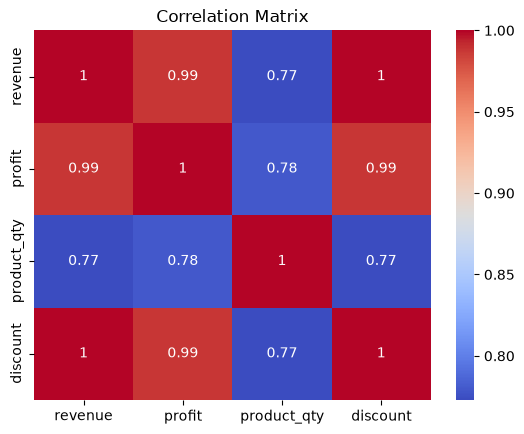

In [63]:
corr = df[['revenue','profit','product_qty','discount']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

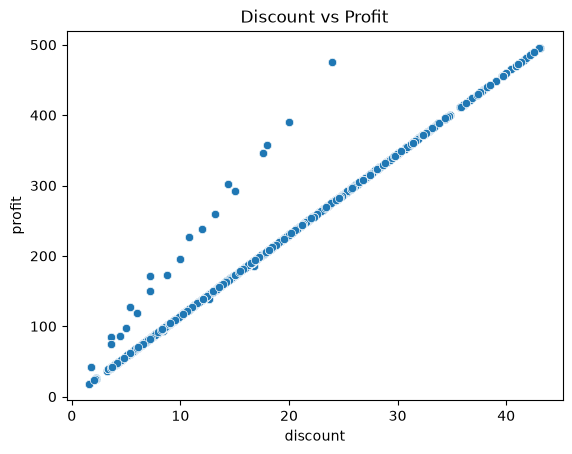

In [64]:
sns.scatterplot(data=df, x='discount', y='profit')
plt.title("Discount vs Profit")
plt.show()

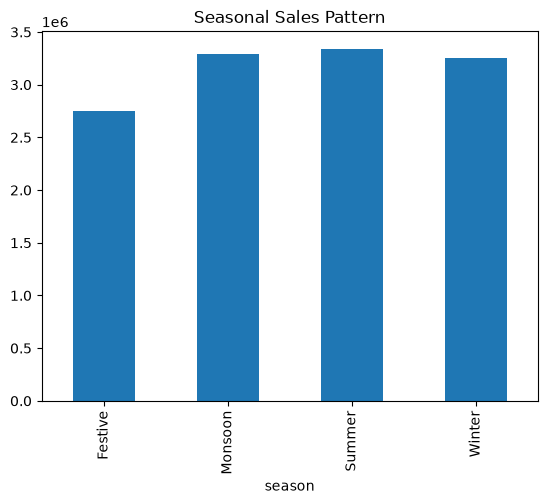

In [69]:
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Summer', 4: 'Summer', 5: 'Summer',
    6: 'Monsoon', 7: 'Monsoon', 8: 'Monsoon',
    9: 'Festive', 10: 'Festive', 11: 'Festive'
}

df['season'] = df['month'].map(season_map)

season_sales = df.groupby('season')['revenue'].sum()

season_sales.plot(kind='bar')
plt.title("Seasonal Sales Pattern")
plt.show()

### RFM SEGMENTATION

In [16]:
rfm_base = df.groupby('customer_id').agg({
    'order_date': ['count', 'max', 'first'],
    'revenue': 'sum',
    'order_id': 'nunique'
}).round(2).reset_index()

In [17]:
rfm_base.columns = ['Customer ID', 'Frequency', 'Recency', 'First Order Date', 
                   'Monetary Value', 'Order Count']

In [18]:
rfm_base['Recency Days'] = (datetime.now() - rfm_base['Recency']).dt.days

In [19]:
rfm_base['Tenure Days'] = (datetime.now() - rfm_base['First Order Date']).dt.days

In [20]:
rfm_base.head()

,Customer ID,Frequency,Recency,First Order Date,Monetary Value,Order Count,Recency Days,Tenure Days
0,1,13,2026-09-20 08:49:15.004,2025-11-17 07:58:59.000,12965.64,13,-78,229
1,2,14,2026-09-13 11:03:39.004,2025-11-13 10:44:35.000,12319.83,14,-71,233
2,3,14,2026-10-06 04:06:43.004,2025-12-23 05:00:51.001,11229.06,14,-94,193
3,4,16,2026-09-28 22:17:39.004,2025-11-19 04:18:03.000,13829.81,16,-87,227
4,5,14,2026-09-23 15:40:19.004,2025-11-03 09:00:35.000,15063.75,14,-82,243


In [21]:
rfm = rfm_base

In [22]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])  
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary Value'], 4, labels=[1,2,3,4])

In [23]:
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

In [24]:
def segment_customer(row):
    r, f, m = int(row['R_score']), int(row['F_score']), int(row['M_score'])
    
    if r >= 4 and f >= 4:
        return "Champions"
    elif r >= 3 and f >= 3:
        return "Loyal Customers"
    elif r >= 3 and f <= 2:
        return "Potential Loyalists"
    elif r <= 2 and f >= 3:
        return "At Risk Customers"
    elif r <= 2 and f <= 2:
        return "Lost Customers"
    else:
        return "Others"

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [71]:
rfm.to_csv('../data/rfm.csv')
rfm.head()

,Customer ID,Frequency,Recency,First Order Date,Monetary Value,Order Count,Recency Days,Tenure Days,R_score,F_score,M_score,RFM_Score,Segment
0,1,13,2026-09-20 08:49:15.004,2025-11-17 07:58:59.000,12965.64,13,-78,229,3,3,4,334,Loyal Customers
1,2,14,2026-09-13 11:03:39.004,2025-11-13 10:44:35.000,12319.83,14,-71,233,3,3,3,333,Loyal Customers
2,3,14,2026-10-06 04:06:43.004,2025-12-23 05:00:51.001,11229.06,14,-94,193,2,3,3,233,At Risk Customers
3,4,16,2026-09-28 22:17:39.004,2025-11-19 04:18:03.000,13829.81,16,-87,227,2,4,4,244,At Risk Customers
4,5,14,2026-09-23 15:40:19.004,2025-11-03 09:00:35.000,15063.75,14,-82,243,3,3,4,334,Loyal Customers


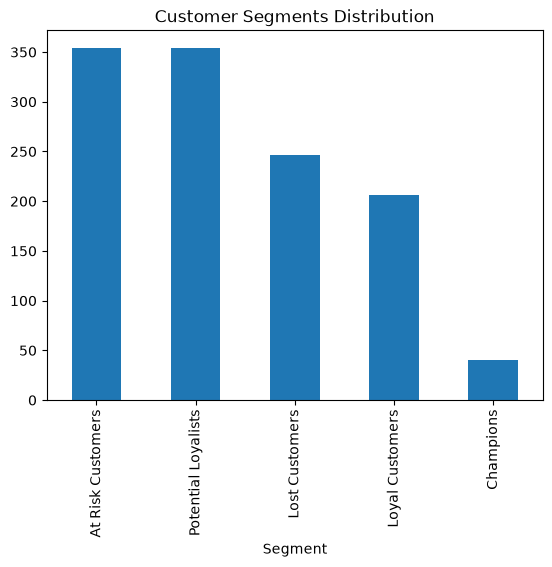

In [26]:
rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments Distribution")
plt.savefig("../reports/customer_segment.png")
plt.show()

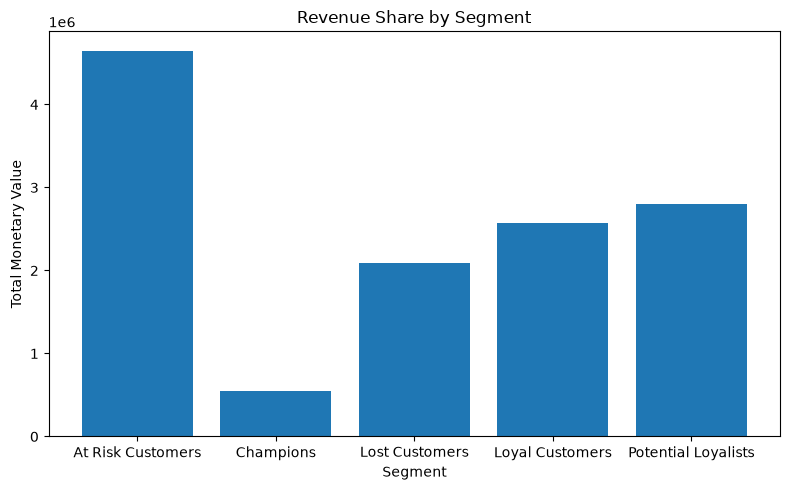

In [27]:
segment_revenue = rfm.groupby('Segment')['Monetary Value'].sum()

plt.figure(figsize=(8,5))
plt.bar(segment_revenue.index, segment_revenue.values)

plt.title('Revenue Share by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Monetary Value')
plt.tight_layout()
plt.savefig('../reports/revenue_share.png')
plt.show()

## **PRS SEGMENTATION**

In [72]:
product_df = df.groupby('product_name').agg({
    'order_date': lambda x: (df['order_date'].max() - x.max()).days,  
    'order_id': 'nunique',                                             
    'product_qty': 'sum',                                         
    'revenue': 'sum',                                                  
    'profit': 'sum',                                                 
    'variant_inventory_qty': 'mean'                                    
})

In [73]:
product_df.rename(columns={
    'order_date': 'Recency',
    'order_id': 'Popularity',
    'product_qty': 'Demand'
}, inplace=True)

In [74]:
product_df['R_score'] = pd.qcut(product_df['Recency'], 4, labels=[4,3,2,1])
product_df['P_score'] = pd.qcut(product_df['Popularity'].rank(method='first'), 4, labels=[1,2,3,4])
product_df['S_score'] = pd.qcut(product_df['revenue'], 4, labels=[1,2,3,4])

In [79]:
def product_segment(row):
    r, p, s = int(row['R_score']), int(row['P_score']), int(row['S_score'])
    
    if p >= 4 and s >= 4:
        return "Hero Products"
    elif p >= 3 and s >= 3:
        return "Best Sellers"
    elif p <= 2 and r <= 2:
        return "Dead Stock"
    elif p <= 2 and s >= 3:
        return "Hidden Gems"
    elif p >= 3 and s <= 2:
        return "High Demand Low Revenue"
    else:
        return "Average Products"

In [80]:
product_df['Segment'] = product_df.apply(product_segment, axis=1)

In [81]:
product_df

,Recency,Popularity,Demand,revenue,profit,variant_inventory_qty,R_score,P_score,S_score,Segment
product_name,,,,,,,,,,
Aloe Vera Body Gel,1,83,199,86497.34,19314.94,3438.0,4,2,3,Hidden Gems
Aloe Vera Face Pack,0,104,280,94018.40,20994.40,2191.0,4,4,3,Best Sellers
Aloe Vera Face Wash,2,87,222,84375.54,18841.14,4148.0,3,3,3,Best Sellers
Aloe Vera Gel,3,87,209,19374.30,8924.30,6488.0,2,3,1,High Demand Low Revenue
Aloe Vera Juice,0,81,221,101750.61,22721.01,6525.0,4,2,4,Hidden Gems
...,...,...,...,...,...,...,...,...,...,...
Turmeric Latte Mix,7,83,211,111055.63,24798.83,2980.0,1,3,4,Best Sellers
Turmeric Powder,0,73,181,38963.87,8700.67,8745.0,4,1,1,Average Products
Turmeric Skin Brightening Cream,0,70,184,91159.12,20355.92,7410.0,4,1,3,Hidden Gems


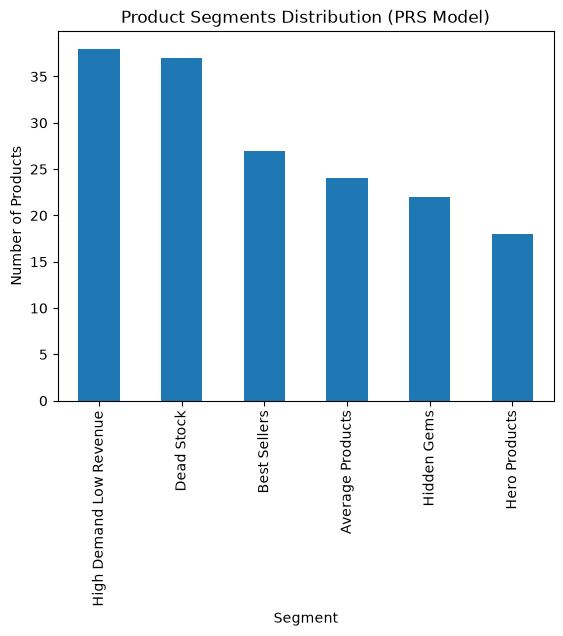

In [82]:
product_df['Segment'].value_counts().plot(kind='bar')
plt.title("Product Segments Distribution (PRS Model)")
plt.xlabel("Segment")
plt.ylabel("Number of Products")
plt.show()

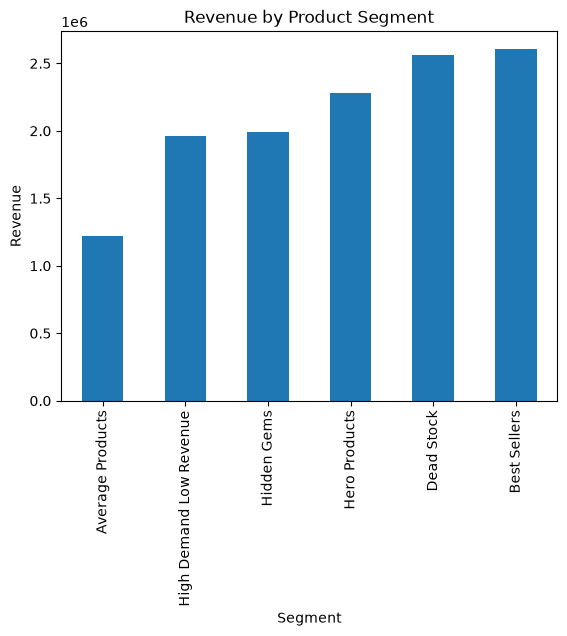

In [83]:
product_df.groupby('Segment')['revenue'].sum().sort_values().plot(kind='bar')
plt.title("Revenue by Product Segment")
plt.xlabel("Segment")
plt.ylabel("Revenue")
plt.show()